In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans

In [2]:
DATA_DIR = Path("../data/CMAPSSData")
IMG_DIR = Path("../images")
IMG_DIR.mkdir(exist_ok=True)

In [3]:
COLS = ["unit", "cycle"] + [f"op_{i}" for i in range(1, 4)] + [f"s_{i}" for i in range(1, 22)]
 
def load(name):
    return pd.read_csv(DATA_DIR / name, sep=r"\s+", header=None, names=COLS, engine="python")

In [4]:
datasets = {}
for ds in ["FD001", "FD002", "FD004"]:
    train = load(f"train_{ds}.txt")
    test = load(f"test_{ds}.txt")
    rul = pd.read_csv(DATA_DIR / f"RUL_{ds}.txt", header=None, names=["RUL"]).squeeze("columns").values
    datasets[ds] = (train, test, rul)
    life_tr = train.groupby("unit").cycle.max().values
    life_te = test.groupby("unit").cycle.max().values + rul
    print(f"{ds}: train {train.shape} ({train.unit.nunique()} units) · "
          f"test {test.shape} ({test.unit.nunique()} units) · "
          f"MTTF_train={life_tr.mean():.0f} std={life_tr.std():.0f}")

FD001: train (20631, 26) (100 units) · test (13096, 26) (100 units) · MTTF_train=206 std=46
FD002: train (53759, 26) (260 units) · test (33991, 26) (259 units) · MTTF_train=207 std=47
FD004: train (61249, 26) (249 units) · test (41214, 26) (248 units) · MTTF_train=246 std=73


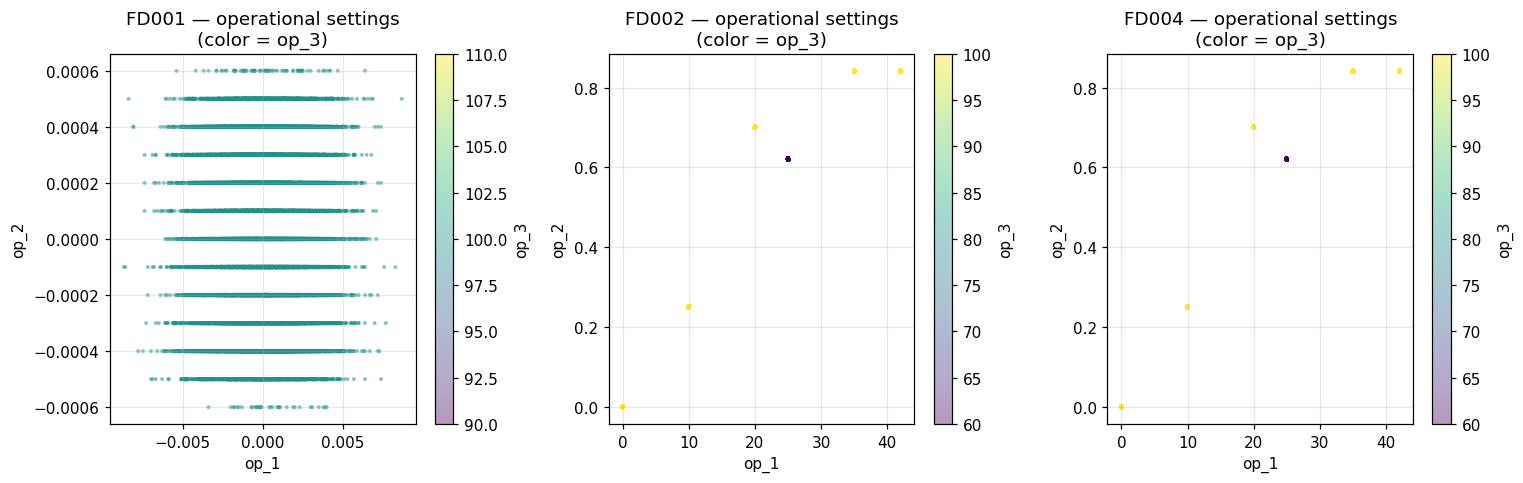

In [5]:
# ========== 1. Operational-settings scatter (op_1, op_2) color by op_3 ==========
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, ds in zip(axes, ["FD001", "FD002", "FD004"]):
    tr = datasets[ds][0]
    sc = ax.scatter(tr.op_1, tr.op_2, c=tr.op_3, s=3, alpha=0.4, cmap="viridis")
    ax.set_xlabel("op_1")
    ax.set_ylabel("op_2")
    ax.set_title(f"{ds} — operational settings\n(color = op_3)")
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label="op_3")
plt.tight_layout()
plt.savefig(IMG_DIR / "20_regime_scatter.png", bbox_inches="tight")
plt.show()
plt.close()

In [6]:
# ========== 2. Fit KMeans(k=6) on FD002 & FD004 op settings ==========
regime_labels = {}
regime_centers = {}
for ds in ["FD002", "FD004"]:
    tr = datasets[ds][0]
    X = tr[["op_1", "op_2", "op_3"]].values
    km = KMeans(n_clusters=6, n_init=10, random_state=0).fit(X)
    tr["regime"] = km.labels_
    regime_labels[ds] = km
    regime_centers[ds] = pd.DataFrame(km.cluster_centers_,
                                      columns=["op_1", "op_2", "op_3"]).round(2)
    print(f"\n{ds} regime centers (KMeans k=6):")
    sizes = pd.Series(km.labels_).value_counts().sort_index()
    regime_centers[ds]["n_rows"] = sizes.values
    print(regime_centers[ds].to_string())


FD002 regime centers (KMeans k=6):
   op_1  op_2   op_3  n_rows
0  42.0  0.84  100.0   13458
1  10.0  0.25  100.0    8096
2  25.0  0.62   60.0    8002
3   0.0  0.00  100.0    8044
4  35.0  0.84  100.0    8037
5  20.0  0.70  100.0    8122

FD004 regime centers (KMeans k=6):
   op_1  op_2   op_3  n_rows
0  42.0  0.84  100.0   15395
1  10.0  0.25  100.0    9224
2  25.0  0.62   60.0    9139
3   0.0  0.00  100.0    9238
4  20.0  0.70  100.0    9091
5  35.0  0.84  100.0    9162


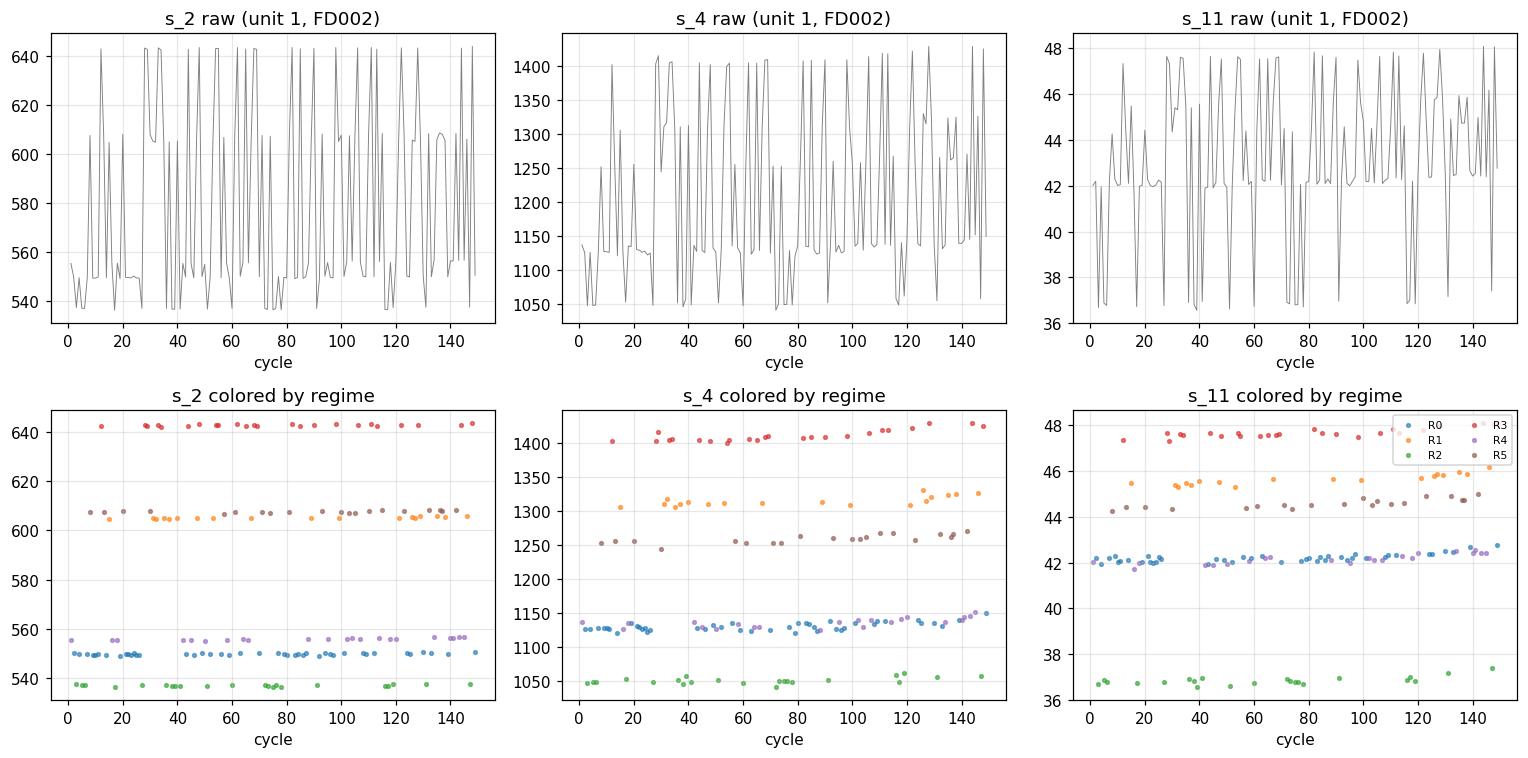

In [7]:
# ========== 3. Show raw sensor "chaos" vs regime-conditional on FD002 ==========
fd002 = datasets["FD002"][0].copy()
fd002["regime"] = regime_labels["FD002"].predict(fd002[["op_1", "op_2", "op_3"]].values)
 
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
demo_sensors = ["s_2", "s_4", "s_11"]
unit_demo = 1
sub = fd002[fd002.unit == unit_demo]
 
for ax, s in zip(axes[0], demo_sensors):
    ax.plot(sub.cycle, sub[s], lw=0.6, color="gray")
    ax.set_title(f"{s} raw (unit {unit_demo}, FD002)")
    ax.set_xlabel("cycle")
    ax.grid(alpha=0.3)
 
for ax, s in zip(axes[1], demo_sensors):
    for r in range(6):
        m = sub.regime == r
        ax.scatter(sub.loc[m, "cycle"], sub.loc[m, s], s=6, alpha=0.6, label=f"R{r}")
    ax.set_title(f"{s} colored by regime")
    ax.set_xlabel("cycle")
    ax.grid(alpha=0.3)
    if s == demo_sensors[-1]:
        ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(IMG_DIR / "21_raw_vs_regime.png", bbox_inches="tight")
plt.show()
plt.close()

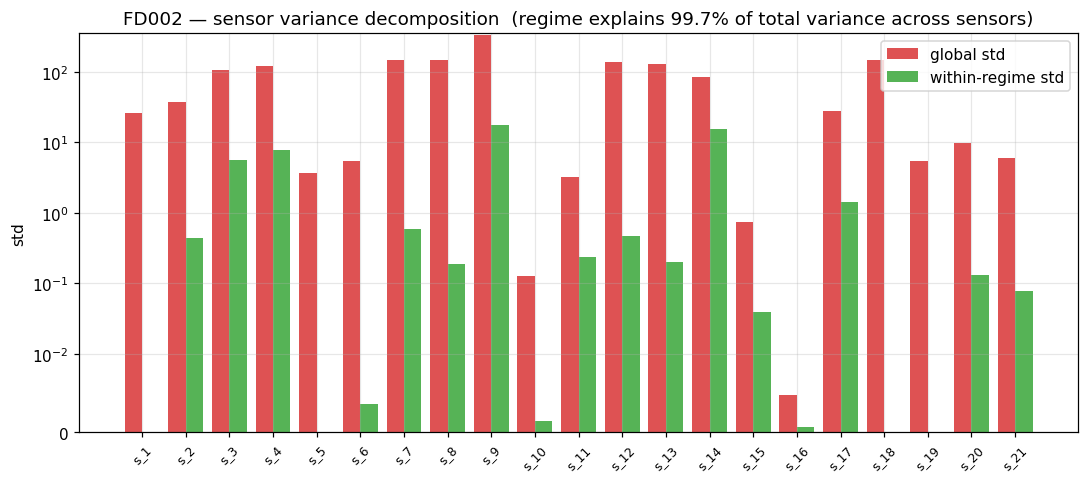

In [8]:

# ========== 4. Sensor std breakdown: global vs within-regime (FD002) ==========
sensor_cols = [f"s_{i}" for i in range(1, 22)]
global_std = fd002[sensor_cols].std()
within_std = fd002.groupby("regime")[sensor_cols].std().mean()
explained = 1 - (within_std ** 2).sum() / (global_std ** 2).sum()
 
df_std = pd.DataFrame({"global_std": global_std, "within_regime_std": within_std})
df_std["ratio"] = df_std["within_regime_std"] / df_std["global_std"].replace(0, np.nan)
 
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(sensor_cols))
w = 0.4
ax.bar(x - w/2, df_std.global_std, w, label="global std", color="tab:red", alpha=0.8)
ax.bar(x + w/2, df_std.within_regime_std, w, label="within-regime std", color="tab:green", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(sensor_cols, rotation=45, fontsize=8)
ax.set_ylabel("std")
ax.set_yscale("symlog", linthresh=0.01)
ax.set_title(f"FD002 — sensor variance decomposition  "
             f"(regime explains {explained:.1%} of total variance across sensors)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "22_variance_decomposition.png", bbox_inches="tight")
plt.show()
plt.close()

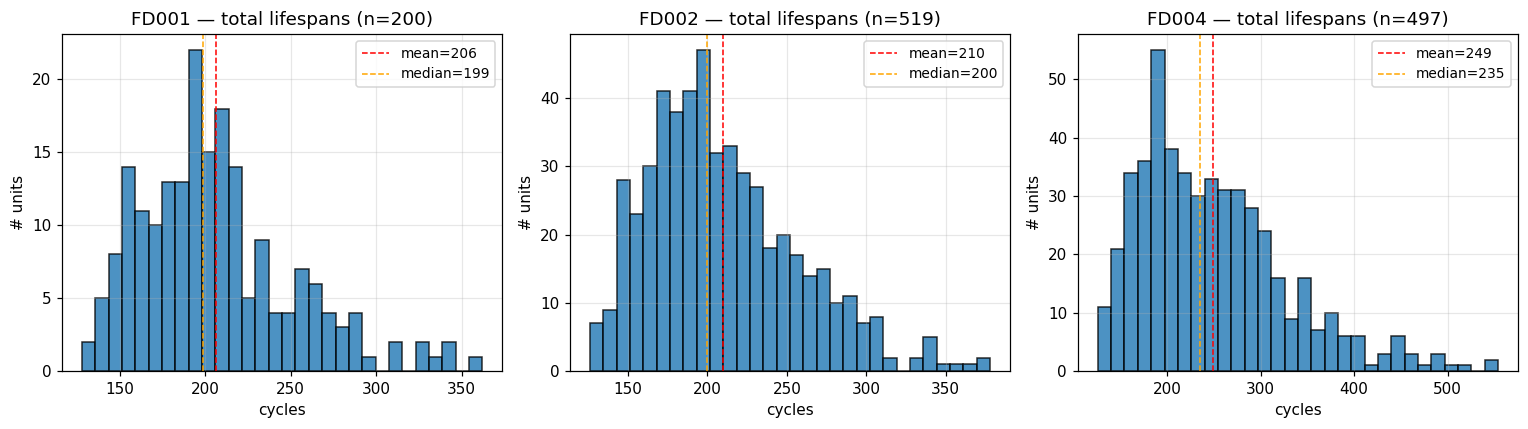


FD002: regime explains 99.7% of cross-sensor variance.


In [9]:
# ========== 5. Lifespan distribution comparison ==========
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ds in zip(axes, ["FD001", "FD002", "FD004"]):
    tr, te, rul = datasets[ds]
    life = np.concatenate([
        tr.groupby("unit").cycle.max().values,
        te.groupby("unit").cycle.max().values + rul,
    ])
    ax.hist(life, bins=30, edgecolor="black", alpha=0.8)
    ax.axvline(life.mean(), color="red", ls="--", lw=1,
               label=f"mean={life.mean():.0f}")
    ax.axvline(np.median(life), color="orange", ls="--", lw=1,
               label=f"median={np.median(life):.0f}")
    ax.set_title(f"{ds} — total lifespans (n={len(life)})")
    ax.set_xlabel("cycles")
    ax.set_ylabel("# units")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / "23_lifespan_compare.png", bbox_inches="tight")
plt.show()
plt.close()
 
print(f"\nFD002: regime explains {explained:.1%} of cross-sensor variance.")